In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

In [7]:
#created dataSet
DATA_PATH = "/home/prateek/Prateek/LaunchPad/week8/Day1/data/data.jsonl"
OUTPUT_PATH = "/home/prateek/Prateek/LaunchPad/week8/Day1/data/cleaned.jsonl"

# df = pd.read_json("hf://datasets/thisisanshgupta/CodeAlpaca/code_alpaca_20k.json")
# df = df[['instruction', 'input', 'output']]
# df = df.head(1000)
# df.to_json(DATA_PATH, orient='records', lines=True)

In [8]:
# check every line is a valid json or not
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        try:
            json.loads(line)
        except Exception as e:
            print(f"Error in line {i}: {e}")


Mean token length: 93.036
Max token length: 598
95th percentile (my 95 percent data is below this token length): 208


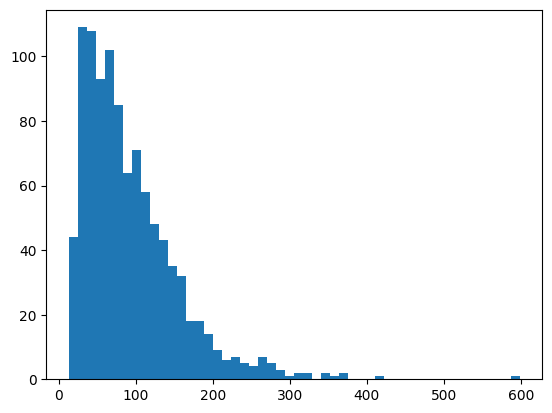

Original samples: 1000
Filtered samples: 950


In [9]:
# Token Length Analysis using mistral tokenizer
# if 1 outlier having length 2048 tokens, rest all are below 500
# tokens. this can be painfull for training as we have to add padding 
# and GPU will do unnecessary computation on those padding tokens


tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")

lengths = [] # array of lengths of the samples
samples = [] 
# array contain [
#                ({sample_1}, length of the sample_1))
#                ({sample_2}, length of the sample_2)),
#               ]

with open(DATA_PATH, "r") as f:
    for line in f:
        sample = json.loads(line)
        text = sample["instruction"] + sample["input"] + sample["output"]
        tokens = tokenizer(text, truncation=False)["input_ids"]
        lengths.append(len(tokens))
        samples.append((sample, len(tokens)))

## =================Max length to cut of outliers==================
MAX_LENGTH = int(np.percentile(lengths, 95)) 
print("Mean token length:", np.mean(lengths))
print("Max token length:", np.max(lengths))
print("95th percentile (my 95 percent data is below this token length):", MAX_LENGTH)

plt.hist(lengths, bins=50)
plt.show()


## =================== remove outliers =====================
filtered_samples = [s for s, l in samples if l <= MAX_LENGTH]

print(f"Original samples: {len(samples)}")
print(f"Filtered samples: {len(filtered_samples)}")

## ================ save filtered samples =================
with open(OUTPUT_PATH, "w") as f:
    for sample in filtered_samples:
        f.write(json.dumps(sample) + "\n")


removed outliers
Mean token length: 83.43578947368421
Max token length: 208
95th percentile (my 95 percent data is below this token length): 172


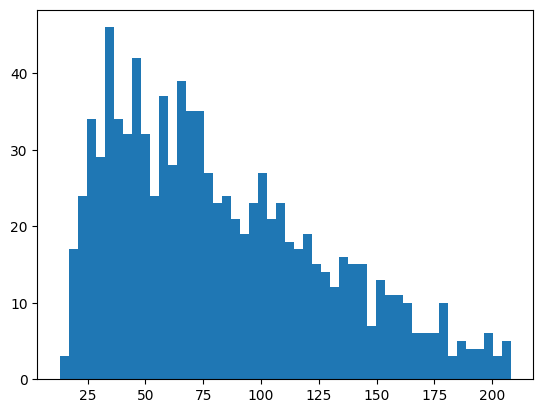

In [10]:
outputLengths = [] # array of lengths of the samples

with open(OUTPUT_PATH, "r") as f:
    for line in f:
        sample = json.loads(line)
        text = sample["instruction"] + sample["input"] + sample["output"]
        tokens = tokenizer(text, truncation=False)["input_ids"]
        outputLengths.append(len(tokens))

print("removed outliers")
print("Mean token length:", np.mean(outputLengths))
print("Max token length:", np.max(outputLengths))
print("95th percentile (my 95 percent data is below this token length):", int(np.percentile(outputLengths, 95)) )

plt.hist(outputLengths, bins=50)
plt.show()

